In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle, ConnectionPatch, FancyArrowPatch, Arrow
from astropy.visualization import ZScaleInterval

from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack, join
from scipy.optimize import curve_fit, root
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
# from hst_phot import *
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis
from prospect.models import priors
from genesis_metallicity.genesis_metallicity import genesis_metallicity
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [53]:
# bestfit = Table(ascii.read('cigale/qref_out/results.txt'))
# input = Table(ascii.read('cigale/qref_out/observations.txt'))
peas = ascii.read('photometry_results.csv')

test = ascii.read('allsources.csv')
tab = test[test['object_id']!= 'STACK']

#### STATISTICAL FITTING CORRECTION
ratio = tab['oiii5007_flux']/tab['oiii4959_flux']
mask = np.isfinite(ratio)
median = np.median(ratio[mask])
tab['oiii4959_flux'] = tab['oiii4959_flux']*(median/3)

SNR_mask = ((tab['oiii5007_flux']/tab['oiii5007_flux_err'])>5)&((tab['oiii4959_flux']/tab['oiii4959_flux_err'])>5)
EW_mask = (tab['oiii5007_ew']>100)|(tab['hbeta_ew']>50)
selection0 = tab[SNR_mask&EW_mask].copy()
common_ids_mask = np.isin(tab['object_id'], peas['object_id'])
selection = tab[common_ids_mask]

musewide = ascii.read('final_table.csv')

True

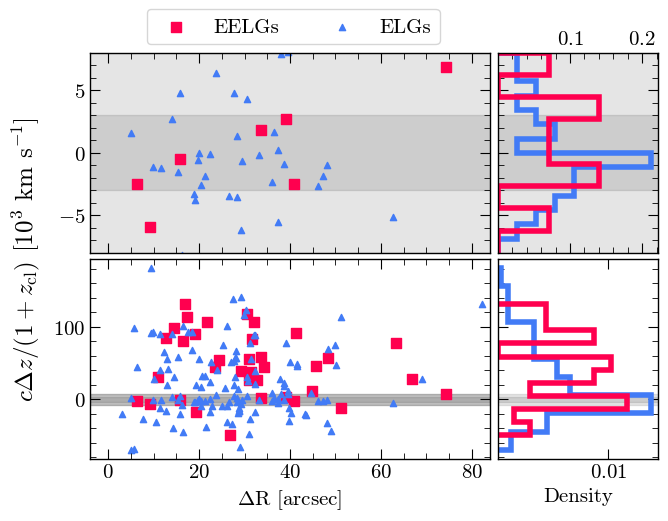

In [16]:
def getrecc(z):
    # return speedoflight.value * ((1+z)**2 - 1) / ((1+z)**2 + 1)
    c = speedoflight.value
    return (((1+z)**2 - 1) / ((1+z)**2 + 1))*c

##############
eelgmask = np.isin(tab['object_id'], selection['object_id'])
elgs = tab[~eelgmask]

### just EELGs ###
recv = getrecc(selection['z'])
clusv = getrecc(selection['zcluster'])
diff = (recv-clusv)/1e6
metric = (speedoflight.value*(selection['z']-selection['zcluster']))/(1+selection['zcluster'])/1e6

# ### whole ELG population ###
recv_all = getrecc(elgs['z'])
clusv_all = getrecc(elgs['zcluster'])
diff_all = (recv_all-clusv_all)/1e6
metric_all = (speedoflight.value*(elgs['z']-elgs['zcluster']))/(1+elgs['zcluster'])/1e6

#### PLOTS #####
fig, ax = pf.create_plot((4,2))
ax2 = fig.add_axes((1.02,0,0.4,1), sharey=ax)
plt.setp(ax2.get_yticklabels(), visible=False)

ax.scatter(selection['angdisp'],metric, c='#ff004f', marker='s', s=50)
ax.scatter(elgs['angdisp'],metric_all, c='#427bf6', marker='^', s=20)

ax2.hist(metric_all, orientation='horizontal', histtype='step', color="#427bf6", density=True, lw=4)
ax2.hist(metric, orientation='horizontal', histtype='step', color='#ff004f', density=True, lw=4)

ax.set_xlim(-4,84)
ax.set_ylim(-82, 194)

ax2.set_xlim(0,0.0145)
ax2.set_xticks([0.01])


for i in [3,8]:
    for a in [ax,ax2]:
        a.fill_between([-100,200],-i,i,alpha=0.1, color='k', zorder=-10)

# Shows the area from ax that ax3 contains
ax.fill_between(ax.get_xlim(), -8, 8, color='grey', alpha=0.3, zorder=-11)

ax.set_xlabel(r'$\Delta$R [arcsec]')
# ax.set_ylabel(r'$c\Delta z / (1+z_{\mathrm{cl}})$ [$10^3$ km s$^{-1}$]')
ax2.set_xlabel('Density')

fig.supylabel(r'$c\Delta z / (1+z_{\mathrm{cl}})$ [$10^3$ km s$^{-1}$]', position=(-.2,1))
### Second Plot ###

ax3 = fig.add_axes((0,1.03,1,1), sharex=ax)
plt.setp(ax3.get_xticklabels(), visible=False)
ax4 = fig.add_axes((1.02,1.03,0.4,1), sharey=ax3)
plt.setp(ax4.get_xticklabels(), visible=False)
plt.setp(ax4.get_yticklabels(), visible=False)

ax3.scatter(selection['angdisp'],metric, c='#ff004f', marker='s', s=50, label='EELGs')
ax3.scatter(elgs['angdisp'],metric_all, c='#427bf6', marker='^', s=20, label='ELGs')

ax4.hist(metric_all, orientation='horizontal', histtype='step', color="#427bf6", density=True, lw=4, bins=np.linspace(-8,8,15))
ax4.hist(metric, orientation='horizontal', histtype='step', color='#ff004f', density=True, lw=4,bins=np.linspace(-8,8,10))

ax3.set_ylim(-8,8)
# ax3.set_ylim(-82, 194)

ax4.set_xlim(0,0.222)
ax4.set_xticks([0.1,0.2])

for i in [3,8]:
    for a in [ax3,ax4]:
        pass
        a.fill_between([-100,200],-i,i,alpha=0.1, color='k', zorder=-10)

ax4.tick_params(labelbottom=False,labeltop=True)

fig.legend(bbox_to_anchor=(.9,2.3), ncol=2)

pf.fix_plot([ax,ax2,ax3,ax4])

In [71]:
redshifts = selection['z']
lum_dist_cm = cosmo.luminosity_distance(redshifts).to(u.cm).value

oiii_flux_cgs = selection['oiii5007_flux'] * 1e-20
oiii_lum = oiii_flux_cgs * 4 * np.pi * lum_dist_cm**2

spitzer_flux_3_6_cgs = peas['flux_Spitzer_I1_3.6'] * 1e-6 * 1e-23
spitzer_flux_4_5_cgs = peas['flux_Spitzer_I2_4.5'] * 1e-6 * 1e-23

l_nu_3_6 = spitzer_flux_3_6_cgs * 4 * np.pi * lum_dist_cm**2
l_nu_4_5 = spitzer_flux_4_5_cgs * 4 * np.pi * lum_dist_cm**2

c_cm_s = 2.998e10  # Speed of light in cm/s
nu_3_6 = c_cm_s / (3.6 * 1e-4)  # 3.6 microns in cm
nu_4_5 = c_cm_s / (4.5 * 1e-4)  # 4.5 microns in cm

spitzer_lum_3_6 = nu_3_6 * l_nu_3_6
spitzer_lum_4_5 = nu_4_5 * l_nu_4_5

cont_est = peas['flux_HST_F435W']+peas['flux_HST_F606W']+peas['flux_HST_F814W']
spit_est = peas['flux_Spitzer_I1_3.6']+peas['flux_Spitzer_I2_4.5']

def get_log10err(tab, key):
    return 0.434*tab[key+'_err']/tab[key]

def pnm(flux, a=0.01, b=0.2):
    return np.sqrt(a * np.abs(1/flux)*50 + b**2)

def get_log10err2(val, err):
    """Calculates the error in log10 space."""
    return np.abs(0.434 * err / val)

oiii_lum_err = get_log10err2(selection['oiii5007_flux'], selection['oiii5007_flux_err'])

spitzer_flux_err_3_6 = pnm(peas['flux_Spitzer_I1_3.6'])
spitzer_flux_err_4_5 = np.abs(pnm(peas['flux_Spitzer_I2_4.5']))

spitzer_lum_3_6_err = get_log10err2(peas['flux_Spitzer_I1_3.6'], spitzer_flux_err_3_6)
spitzer_lum_4_5_err = get_log10err2(peas['flux_Spitzer_I2_4.5'], spitzer_flux_err_4_5)

logspitzer_flux_err_4_5 = get_log10err2(peas['flux_Spitzer_I2_4.5'],spitzer_flux_err_4_5)
logspitzer_flux_err_3_6 = get_log10err2(peas['flux_Spitzer_I1_3.6'],spitzer_flux_err_3_6)

colordiff = -2.5*np.log10(spitzer_flux_3_6_cgs/spitzer_flux_4_5_cgs)
frac = (spitzer_flux_3_6_cgs/spitzer_flux_4_5_cgs)
fracerr = frac*np.sqrt(
    (spitzer_flux_err_3_6/peas['flux_Spitzer_I1_3.6'])**2+
    (spitzer_flux_err_4_5/peas['flux_Spitzer_I2_4.5'])**2)
colordifferr = 0.482*fracerr/frac


def get_R23(sel):
    R23 = ((sel['oiii5007_flux']+sel['oiii4959_flux']+sel['oii3726_flux']+sel['oii3729_flux'])/sel['hbeta_flux']).data
    num_r23 = np.array((sel['oiii5007_flux'],sel['oiii4959_flux'],sel['oii3726_flux'],sel['oii3729_flux']))
    num_r23_err = np.array((sel['oiii5007_flux_err'],sel['oiii4959_flux_err'],sel['oii3726_flux_err'],sel['oii3729_flux_err']))
    R23_err = (np.sqrt((np.sqrt(np.sum(num_r23_err**2,axis=0))/np.sum(num_r23, axis=0))**2 + (sel['hbeta_flux_err'].data/sel['hbeta_flux'].data)**2)*R23)
    return R23, R23_err

R23, R23_err = get_R23(selection)

def get_O32(sel):
    num_o32 = np.array(sel['oiii5007_flux'])
    num_o32_err = np.array(sel['oiii5007_flux_err'])
    denom_o32 = np.array([sel['oii3729_flux'],sel['oii3726_flux']])
    denom_o32_err = np.array([sel['oii3729_flux_err'],sel['oii3726_flux_err']])
    O32 = num_o32/np.sum(denom_o32, axis=0)
    O32_err = np.sqrt((num_o32_err/num_o32)**2+(np.sqrt(np.sum(denom_o32_err**2, axis=0))/np.sum(denom_o32, axis=0))**2)*O32
    return O32, O32_err

O32, O32_err = get_O32(selection)

SNRmask = (O32/O32_err>5)&(R23/R23_err>5)

selection['colordiff'] = colordiff
selection['colordiff_err'] = colordifferr
colordiff[colordiff==0] = np.nan

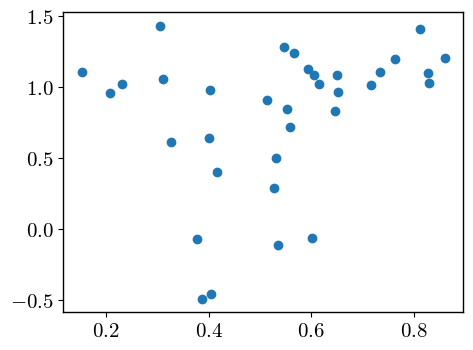

In [28]:
fig, ax = pf.create_plot()

ax.scatter(selection['z'], colordiff)

True

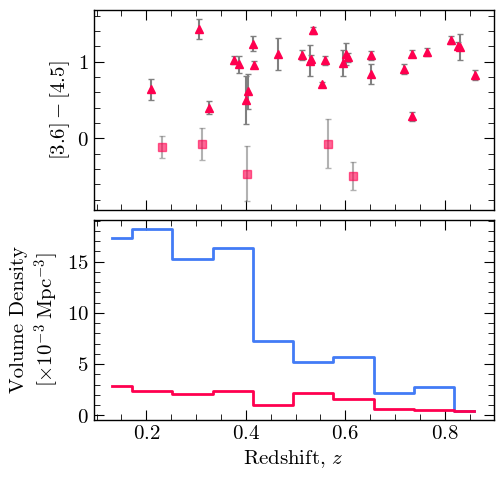

In [87]:
fig, ax = pf.create_plot((4,2))

ax.set_ylabel('Volume Density\n'+r'[$\times10^{-3}\;$Mpc$^{-3}$]')
ax.set_xlabel(r'Redshift, $z$')

colors = ['#427bf6','#ff004f']
labels = ['ELGs', 'EELGs']

for ii,z in enumerate([tab['z'],selection['z']]):
    survey_area_sq_arcmin = 38.0

    # Redshift range and binning
    z_min = 0.09
    z_max = 0.9
    z_bins = np.linspace(z_min, z_max, 11) # 10 bins from 0.3 to 0.8

    # --- Calculations ---

    # 1. Convert survey area to steradians
    survey_area = survey_area_sq_arcmin * (u.arcmin**2)
    survey_area_sr = survey_area.to(u.sr)

    # 2. Get the number of galaxies in each redshift bin
    galaxy_counts, _ = np.histogram(z, bins=z_bins)

    # 3. Calculate the comoving volume for each bin
    bin_volumes = []
    for i in range(len(z_bins) - 1):
        z_low = z_bins[i]
        z_high = z_bins[i+1]
        
        # Calculate the comoving volume of the shell for the full sky
        v_low = cosmo.comoving_volume(z_low)
        v_high = cosmo.comoving_volume(z_high)
        shell_volume = v_high - v_low
        
        # Scale the volume to your survey area
        # The full sky is 4*pi steradians
        volume_in_bin = shell_volume * (survey_area_sr.value / (4 * np.pi))
        bin_volumes.append(volume_in_bin.to(u.Mpc**3).value)

    bin_volumes = np.array(bin_volumes)

    # 4. Calculate the volume density (number of galaxies per cubic Megaparsec)
    # Avoid division by zero if a bin has zero volume (though unlikely here)
    volume_density = np.divide(galaxy_counts, bin_volumes, out=np.zeros_like(galaxy_counts, dtype=float), where=bin_volumes!=0)

    # Get the center of each redshift bin for plotting
    z_bin_centers = (z_bins[:-1] + z_bins[1:]) / 2

    ax.step(z_bin_centers, volume_density*1e3, where='mid', color=colors[ii], lw=2)


ax2 = fig.add_axes((0,1.05,1,1), sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)

ax2.set_ylabel('$[3.6]-[4.5]$')

fmts = ['^', 's']

for i, data in enumerate([selection[colordiff>0], selection[colordiff<0]]):
    ax2.errorbar(data['z'], data['colordiff'], yerr=data['colordiff_err'], 
                 fmt=fmts[i], ecolor='gray', capsize=2, color='#ff004f', alpha=(1-0.4*i))

pf.fix_plot([ax,ax2])

UNIQUE_ID,FIELD_NAME,RA,DEC,Z,Z_ERR,LEAD_LINE,SN,QUALITY,CONFIDENCE,OTHER_LINES,GUO_ID,GUO_SEP,SKELTON_ID,SKELTON_SEP,STELLAR_MASS,DETECTED?_OIII,WFoiii5007_flux,WFoiii5007_flux_err,WFoiii5007_centroid,WFoiii4959_flux,WFoiii4959_flux_err,WFoiii4959_centroid,WFoii_flux,WFoii_flux_err,WFoii_centroid,WFhalpha_flux,WFhalpha_flux_err,WFhalpha_centroid,WFhbeta_flux,WFhbeta_flux_err,WFhbeta_centroid,DETECTED?_Hb,RAJ2000,DEJ2000,F606W,e_F606W,F814W,e_F814W,F125W,e_F125W,F140W,e_F140W,F160W,e_F160W,WFoiii5007_ew,WFoiii4959_ew,WFhbeta_ew
int64,str15,float64,float64,float64,float64,str4,float64,str1,int64,str51,int64,float64,int64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
117019062,candels-cdfs-17,53.161029297195135,-27.845648854888942,4.793310165405273,0.00023999999393709004,Lya,10.52396752732081,c,2,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
145034089,candels-cdfs-45,53.04941724959954,-27.792198819978907,4.1996169090271,0.001421791035681963,Lya,5.116736888885498,c,1,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
145039097,candels-cdfs-45,53.054002647564594,-27.787527318729325,4.439391136169434,0.0016438179882243276,Lya,5.855274200439453,c,2,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
145044103,candels-cdfs-45,53.065669197780146,-27.79666829596328,4.814822196960449,0.0012466150801628828,Lya,5.613737106323242,c,1,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
145045104,candels-cdfs-45,53.04976102084865,-27.793577412836758,4.9472455978393555,0.0005344867240637541,Lya,5.00687837600708,c,1,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
122007063,candels-cdfs-22,53.13911296624889,-27.83634142031768,3.1427299976348877,0.0008500000112690032,Lya,7.440158426679493,c,2,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
122005056,candels-cdfs-22,53.13780810151262,-27.83360371579142,3.0648000240325928,0.00039000000106170774,Lya,6.531986707112724,c,2,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
122004055,candels-cdfs-22,53.12691331467025,-27.839296486180462,3.065150022506714,0.0002699999895412475,Lya,8.714166836436174,c,2,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
122002035,candels-cdfs-22,53.11979600543306,-27.831269289007015,5.319019794464111,0.000859999970998615,Lya,8.362678963964123,c,1,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
